# Problem 8: Employee Attrition Prediction with Google TabFM

We build an end-to-end attrition risk pipeline to classify whether an employee is likely to **Leave** or **Stay**, then convert predictions into actionable retention policy decisions.


## 0) Why this design

This notebook is intentionally production-oriented:

- Uses a real web-hosted HR attrition dataset and caches locally.
- Builds a strong baseline (`XGBoost`) and compares against multiple **TabFM** variants.
- Handles class imbalance, calibration, and threshold optimization.
- Converts probabilities into retention actions (`priority_retention`, `watchlist`, `stable`).
- Persists metrics, predictions, and policy artifacts for downstream BI / ops.


## 1) Reproducible setup

Environment knobs (optional):

- `TABFM_DEVICE=auto|cpu|cuda`
- `ATTRITION_DATA_URL=<csv_url>`
- `ATTRITION_SAMPLE_TRAIN_ROWS=0` (0 means full split)
- `ATTRITION_SAMPLE_EVAL_ROWS=0` (0 means full split)
- `ATTRITION_MIN_SAMPLE_ROWS=200`
- `TABFM_CONTEXT_MAX_ROWS=1500`
- `TABFM_EVAL_MAX_ROWS=3000`
- `TABFM_FAST_MODE=0|1`
- `TABFM_CHECKPOINT_PATH=<path to local checkpoint>`


In [1]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import torch
from loguru import logger
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

from tabfm import TabFMClassifier
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TABFM_DEVICE_PREF = os.getenv('TABFM_DEVICE', 'auto').lower().strip()
if TABFM_DEVICE_PREF not in {'auto', 'cpu', 'cuda'}:
    raise ValueError(f'Unsupported TABFM_DEVICE={TABFM_DEVICE_PREF}')

DATA_URL = os.getenv(
    'ATTRITION_DATA_URL',
    'https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv',
).strip()
SAMPLE_TRAIN_ROWS = int(os.getenv('ATTRITION_SAMPLE_TRAIN_ROWS', '0'))
SAMPLE_EVAL_ROWS = int(os.getenv('ATTRITION_SAMPLE_EVAL_ROWS', '0'))
MIN_SAMPLE_ROWS = int(os.getenv('ATTRITION_MIN_SAMPLE_ROWS', '200'))
TABFM_CONTEXT_MAX_ROWS = int(os.getenv('TABFM_CONTEXT_MAX_ROWS', '1500'))
TABFM_EVAL_MAX_ROWS = int(os.getenv('TABFM_EVAL_MAX_ROWS', '3000'))
TABFM_FAST_MODE = os.getenv('TABFM_FAST_MODE', '0').strip() == '1'
TABFM_CHECKPOINT_OVERRIDE = os.getenv('TABFM_CHECKPOINT_PATH', '').strip()

if SAMPLE_TRAIN_ROWS != 0 and SAMPLE_TRAIN_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'ATTRITION_SAMPLE_TRAIN_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if SAMPLE_EVAL_ROWS != 0 and SAMPLE_EVAL_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'ATTRITION_SAMPLE_EVAL_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if TABFM_CONTEXT_MAX_ROWS <= 300:
    raise ValueError('TABFM_CONTEXT_MAX_ROWS must be > 300 for stable TabFM fitting.')
if TABFM_EVAL_MAX_ROWS != 0 and TABFM_EVAL_MAX_ROWS <= 300:
    raise ValueError('TABFM_EVAL_MAX_ROWS must be 0 or > 300.')


def resolve_tabfm_device(preference: str) -> str:
    if preference == 'auto':
        return 'cuda' if torch.cuda.is_available() else 'cpu'
    if preference == 'cuda' and not torch.cuda.is_available():
        logger.warning('TABFM_DEVICE=cuda requested but CUDA unavailable; falling back to cpu')
        return 'cpu'
    return preference


def find_project_root(start: Path) -> Path:
    for cand in [start, *start.parents]:
        if (cand / 'pyproject.toml').exists():
            return cand
    raise RuntimeError('Could not find project root (pyproject.toml not found).')


PROJECT_ROOT = find_project_root(Path.cwd())
PROBLEM_ROOT = PROJECT_ROOT / 'problems' / 'problem8_employee_attrition_prediction'
DATA_DIR = PROBLEM_ROOT / 'data' / 'raw'
ARTIFACT_DIR = PROBLEM_ROOT / 'artifacts'

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = resolve_tabfm_device(TABFM_DEVICE_PREF)
TABFM_CKPT_PATH = Path(TABFM_CHECKPOINT_OVERRIDE) if TABFM_CHECKPOINT_OVERRIDE else None

logger.info('Project root: {}', PROJECT_ROOT)
logger.info('Problem root: {}', PROBLEM_ROOT)
logger.info('Raw data dir: {}', DATA_DIR)
logger.info('Artifacts dir: {}', ARTIFACT_DIR)
logger.info('Dataset URL: {}', DATA_URL)
logger.info('TabFM device preference={} effective={}', TABFM_DEVICE_PREF, DEVICE)
logger.info('Sample train/eval rows: {}/{} (0 means full)', SAMPLE_TRAIN_ROWS, SAMPLE_EVAL_ROWS)
logger.info('TabFM context max rows: {}', TABFM_CONTEXT_MAX_ROWS)
logger.info('TabFM eval max rows: {} (0 means full)', TABFM_EVAL_MAX_ROWS)
logger.info('TabFM fast mode: {}', TABFM_FAST_MODE)
logger.info('TabFM checkpoint override: {}', TABFM_CKPT_PATH)

sns.set_theme(style='whitegrid')


2026-07-03 05:19:22.130 | INFO     | __main__:<module>:97 - Project root: /home/ahmad/AI/Github/google-tabFM-implementation


2026-07-03 05:19:22.131 | INFO     | __main__:<module>:98 - Problem root: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction


2026-07-03 05:19:22.131 | INFO     | __main__:<module>:99 - Raw data dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/data/raw


2026-07-03 05:19:22.132 | INFO     | __main__:<module>:100 - Artifacts dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts


2026-07-03 05:19:22.132 | INFO     | __main__:<module>:101 - Dataset URL: https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv


...

2026-07-03 05:19:22.133 | INFO     | __main__:<module>:103 - Sample train/eval rows: 0/0 (0 means full)


2026-07-03 05:19:22.134 | INFO     | __main__:<module>:104 - TabFM context max rows: 1200


2026-07-03 05:19:22.134 | INFO     | __main__:<module>:105 - TabFM eval max rows: 600 (0 means full)


2026-07-03 05:19:22.134 | INFO     | __main__:<module>:106 - TabFM fast mode: True


2026-07-03 05:19:22.134 | INFO     | __main__:<module>:107 - TabFM checkpoint override: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


## 2) Download dataset directly from web

Source dataset (IBM HR Attrition):

- URL: `https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv`
- Binary target: `Attrition` (`Yes` / `No`)

We cache locally after first download.


In [2]:
CACHE_CSV = DATA_DIR / 'employee_attrition_ibm.csv'

if CACHE_CSV.exists():
    df = pd.read_csv(CACHE_CSV)
    logger.info('Loaded cached dataset {} shape={}', CACHE_CSV, df.shape)
else:
    df = pd.read_csv(DATA_URL)
    logger.info('Downloaded dataset from {} shape={}', DATA_URL, df.shape)

# Normalize column names (BOM-safe + whitespace-safe).
df.columns = [str(c).replace('﻿', '').strip() for c in df.columns]

# Persist cache for reproducible reruns.
df.to_csv(CACHE_CSV, index=False)
logger.info('Cached dataset at {}', CACHE_CSV)

CACHE_CSV


2026-07-03 05:19:22.147 | INFO     | __main__:<module>:5 - Loaded cached dataset /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/data/raw/employee_attrition_ibm.csv shape=(1470, 35)


2026-07-03 05:19:22.157 | INFO     | __main__:<module>:15 - Cached dataset at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/data/raw/employee_attrition_ibm.csv


PosixPath('/home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/data/raw/employee_attrition_ibm.csv')

## 3) Clean and audit data

We normalize labels to `0/1`:

- `1` = Leave
- `0` = Stay

Then verify class balance and schema quality.


In [3]:
TARGET_COL = 'Attrition'

if TARGET_COL not in df.columns:
    raise ValueError(f'Missing target column: {TARGET_COL}')


def normalize_binary_target(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype('int64')

    s = series.copy()
    numeric = pd.to_numeric(s, errors='coerce')

    mapped = pd.Series(np.nan, index=s.index, dtype='float64')
    mapped.loc[numeric.isin([0, 1])] = numeric.loc[numeric.isin([0, 1])]

    remaining = mapped.isna()
    if remaining.any():
        text = s.astype(str).str.strip().str.lower()
        positive = {'1', 'true', 'yes', 'y', 'leave', 'left', 'quit', 'resigned'}
        negative = {'0', 'false', 'no', 'n', 'stay', 'stayed', 'active'}
        mapped.loc[remaining & text.isin(positive)] = 1.0
        mapped.loc[remaining & text.isin(negative)] = 0.0

    return mapped


logger.info('Raw target value counts (top 10): {}', df[TARGET_COL].astype(str).str.lower().value_counts(dropna=False).head(10).to_dict())

# Clean object fields.
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()

df[TARGET_COL] = normalize_binary_target(df[TARGET_COL])
df = df[df[TARGET_COL].notna()].copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)
df = df[df[TARGET_COL].isin([0, 1])].reset_index(drop=True)

if len(df) < 800:
    raise ValueError(f'Dataset too small after cleaning (rows={len(df)}).')

if 'EmployeeNumber' in df.columns:
    emp_num = pd.to_numeric(df['EmployeeNumber'], errors='coerce')
    fallback_ids = pd.Series(np.arange(len(df), dtype=np.int64), index=df.index)
    employee_id = emp_num.where(emp_num.notna(), fallback_ids).astype(np.int64)
    df.insert(0, 'employee_id', employee_id)
else:
    df.insert(0, 'employee_id', np.arange(len(df), dtype=np.int64))

df = df.drop_duplicates(subset=['employee_id']).reset_index(drop=True)

class_counts = df[TARGET_COL].value_counts().sort_index()
attrition_rate = float(df[TARGET_COL].mean())

logger.info('Clean shape: {}', df.shape)
logger.info('Class distribution: {}', class_counts.to_dict())
logger.info('Attrition rate: {:.2%}', attrition_rate)

pd.DataFrame([
    {'metric': 'rows', 'value': len(df)},
    {'metric': 'columns', 'value': df.shape[1]},
    {'metric': 'attrition_rate', 'value': attrition_rate},
    {'metric': 'leave_count', 'value': int(class_counts.get(1, 0))},
    {'metric': 'stay_count', 'value': int(class_counts.get(0, 0))},
])


2026-07-03 05:19:22.171 | INFO     | __main__:<module>:28 - Raw target value counts (top 10): {'no': 1233, 'yes': 237}


/tmp/ipykernel_379209/1329961370.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include=['object']).columns:
2026-07-03 05:19:22.179 | INFO     | __main__:<module>:55 - Clean shape: (1470, 36)


2026-07-03 05:19:22.179 | INFO     | __main__:<module>:56 - Class distribution: {0: 1233, 1: 237}


2026-07-03 05:19:22.180 | INFO     | __main__:<module>:57 - Attrition rate: 16.12%


,metric,value
0,rows,1470.000000
1,columns,36.000000
2,attrition_rate,0.161224
3,leave_count,237.000000
4,stay_count,1233.000000


/tmp/ipykernel_379209/1851506443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_counts.index, y=plot_counts.values, palette='viridis')


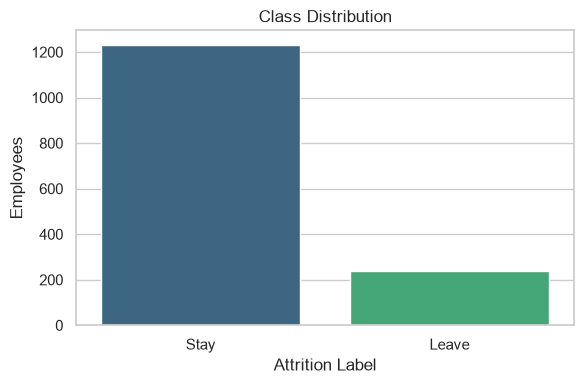

In [4]:
plt.figure(figsize=(6, 4))
plot_counts = df[TARGET_COL].value_counts().rename(index={0: 'Stay', 1: 'Leave'})
sns.barplot(x=plot_counts.index, y=plot_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.ylabel('Employees')
plt.xlabel('Attrition Label')
plt.tight_layout()
plt.show()


## 4) Feature engineering

We add HR-domain features tied to attrition dynamics:

- tenure and promotion progression
- overtime / work intensity signals
- manager continuity signals
- engagement composite score
- salary and experience interactions


In [5]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()

    # Remove near-constant columns commonly present in this dataset.
    for c in ['EmployeeCount', 'Over18', 'StandardHours']:
        if c in out.columns:
            out = out.drop(columns=[c])

    # Numeric safety for transformation columns.
    numeric_cols = [
        'MonthlyIncome',
        'JobLevel',
        'YearsAtCompany',
        'YearsInCurrentRole',
        'YearsSinceLastPromotion',
        'YearsWithCurrManager',
        'TotalWorkingYears',
        'DistanceFromHome',
        'NumCompaniesWorked',
        'PercentSalaryHike',
        'PerformanceRating',
        'TrainingTimesLastYear',
        'WorkLifeBalance',
        'JobSatisfaction',
        'EnvironmentSatisfaction',
        'RelationshipSatisfaction',
        'JobInvolvement',
    ]
    for c in numeric_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')

    # Attrition-relevant interactions.
    out['income_per_job_level'] = out.get('MonthlyIncome', np.nan) / np.maximum(out.get('JobLevel', 1), 1)
    out['tenure_role_ratio'] = out.get('YearsInCurrentRole', np.nan) / np.maximum(out.get('YearsAtCompany', 1), 1)
    out['promotion_wait_ratio'] = out.get('YearsSinceLastPromotion', np.nan) / np.maximum(out.get('YearsAtCompany', 1), 1)
    out['manager_gap_years'] = out.get('YearsAtCompany', np.nan) - out.get('YearsWithCurrManager', np.nan)
    out['experience_stability_index'] = out.get('TotalWorkingYears', np.nan) - out.get('NumCompaniesWorked', np.nan)

    # Composite engagement and work pressure signals.
    engagement_cols = [c for c in ['JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction'] if c in out.columns]
    out['engagement_index'] = out[engagement_cols].mean(axis=1) if engagement_cols else np.nan

    out['work_intensity_index'] = (
        out.get('DistanceFromHome', 0).fillna(0)
        + out.get('NumCompaniesWorked', 0).fillna(0)
        + out.get('TrainingTimesLastYear', 0).fillna(0)
    )

    out['salary_hike_x_perf'] = out.get('PercentSalaryHike', np.nan) * out.get('PerformanceRating', np.nan)

    # Useful categorical buckets for richer tabular patterns.
    if 'MonthlyIncome' in out.columns:
        out['income_band'] = pd.cut(
            out['MonthlyIncome'],
            bins=[-1, 3000, 6000, 10000, 15000, np.inf],
            labels=['very_low', 'low', 'mid', 'high', 'very_high'],
        ).astype(object)

    if 'YearsAtCompany' in out.columns:
        out['tenure_band'] = pd.cut(
            out['YearsAtCompany'],
            bins=[-1, 1, 3, 7, 12, np.inf],
            labels=['new_hire', 'early', 'developing', 'experienced', 'long_tenure'],
        ).astype(object)

    return out


feature_df = engineer_features(df)
feature_df[['employee_id', 'MonthlyIncome', 'YearsAtCompany', 'engagement_index', TARGET_COL]].head()


,employee_id,MonthlyIncome,YearsAtCompany,engagement_index,Attrition
0,1,5993,6,2.50,1
1,2,5130,10,2.75,0
2,4,2090,0,2.75,1
3,5,2909,8,3.25,0
4,7,3468,2,2.50,0


## 5) Train / validation / test split

We use stratified splits and optional row caps to control runtime.


In [6]:
META_COLS = ['employee_id', TARGET_COL, 'MonthlyIncome', 'Department', 'JobRole']


def cap_split_rows(df_split: pd.DataFrame, max_rows: int, seed: int, target_col: str, min_pos: int = 30) -> pd.DataFrame:
    if max_rows == 0 or len(df_split) <= max_rows:
        return df_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    pos = df_split[df_split[target_col] == 1]
    neg = df_split[df_split[target_col] == 0]

    if len(pos) == 0 or len(neg) == 0:
        return df_split.sample(n=max_rows, random_state=seed).reset_index(drop=True)

    desired_pos = min(len(pos), max(min_pos, int(round(max_rows * len(pos) / len(df_split)))))
    desired_pos = min(desired_pos, max_rows - 1)
    desired_neg = max_rows - desired_pos

    pos_sample = pos.sample(n=desired_pos, random_state=seed)
    neg_sample = neg.sample(n=desired_neg, random_state=seed)

    return pd.concat([pos_sample, neg_sample], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)


train_full, holdout = train_test_split(
    feature_df,
    test_size=0.30,
    random_state=SEED,
    stratify=feature_df[TARGET_COL],
)
val_full, test_full = train_test_split(
    holdout,
    test_size=0.50,
    random_state=SEED,
    stratify=holdout[TARGET_COL],
)

train_df = cap_split_rows(train_full, SAMPLE_TRAIN_ROWS, seed=SEED + 1, target_col=TARGET_COL)
val_df = cap_split_rows(val_full, SAMPLE_EVAL_ROWS, seed=SEED + 2, target_col=TARGET_COL)
test_df = cap_split_rows(test_full, SAMPLE_EVAL_ROWS, seed=SEED + 3, target_col=TARGET_COL)

pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'leave': int(train_df[TARGET_COL].sum()), 'leave_rate': float(train_df[TARGET_COL].mean())},
    {'split': 'val', 'rows': len(val_df), 'leave': int(val_df[TARGET_COL].sum()), 'leave_rate': float(val_df[TARGET_COL].mean())},
    {'split': 'test', 'rows': len(test_df), 'leave': int(test_df[TARGET_COL].sum()), 'leave_rate': float(test_df[TARGET_COL].mean())},
])


,split,rows,leave,leave_rate
0,train,1029,166,0.161322
1,val,220,35,0.159091
2,test,221,36,0.162896


## 6) Modeling helpers + XGBoost baseline

Baseline first, then TabFM variants.


In [7]:
def evaluate_classifier(y_true: np.ndarray, y_score: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    return {
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'brier': float(brier_score_loss(y_true, y_score)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }


def make_model_xy(frame: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    y = frame[TARGET_COL].to_numpy(dtype=np.int32)
    meta = frame[[c for c in META_COLS if c in frame.columns]].reset_index(drop=True)

    X = frame.drop(columns=[TARGET_COL]).copy()

    if 'employee_id' in X.columns:
        X = X.drop(columns=['employee_id'])

    # EmployeeNumber is a unique identifier and can leak patterns; remove it.
    if 'EmployeeNumber' in X.columns:
        X = X.drop(columns=['EmployeeNumber'])

    X = X.where(pd.notna(X), np.nan)

    non_numeric_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    for col in non_numeric_cols:
        X[col] = X[col].astype(object)

    return X, y, meta


X_train, y_train, train_meta = make_model_xy(train_df)
X_val, y_val, val_meta = make_model_xy(val_df)
X_test, y_test, test_meta = make_model_xy(test_df)

num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

logger.info('Feature columns total={} num={} cat={}', len(X_train.columns), len(num_cols), len(cat_cols))


def train_xgboost_baseline(X: pd.DataFrame, y: np.ndarray) -> Pipeline:
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    scale_pos_weight = max(1.0, n_neg / max(1, n_pos))

    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

    model = XGBClassifier(
        n_estimators=220,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=SEED,
        eval_metric='aucpr',
        tree_method='hist',
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model),
    ])
    pipe.fit(X, y)
    return pipe


def get_scores(model: Any, X: pd.DataFrame) -> np.ndarray:
    proba = np.asarray(model.predict_proba(X))
    if proba.ndim != 2 or proba.shape[1] != 2:
        raise ValueError(f'Expected binary predict_proba [N,2], got {proba.shape}')
    return proba[:, 1].astype(float)


t0 = time.time()
xgb_model = train_xgboost_baseline(X_train, y_train)
logger.info('XGBoost training completed in {:.1f}s', time.time() - t0)


2026-07-03 05:19:22.368 | INFO     | __main__:<module>:46 - Feature columns total=40 num=31 cat=9


2026-07-03 05:19:22.577 | INFO     | __main__:<module>:98 - XGBoost training completed in 0.2s


## 7) Robust TabFM checkpoint loading


In [8]:
def _candidate_tabfm_paths() -> list[Path]:
    candidates: list[Path] = []

    if TABFM_CKPT_PATH is not None:
        candidates.append(TABFM_CKPT_PATH)

    # Reuse known local checkpoint from prior runs.
    known_local = PROJECT_ROOT / 'problems' / 'problem2_saas_subscription_churn' / 'data' / 'models' / 'google-tabfm-1.0.0-pytorch'
    if known_local.exists():
        candidates.append(known_local)

    hf_root = Path.home() / '.cache' / 'huggingface' / 'hub' / 'models--google--tabfm-1.0.0-pytorch' / 'snapshots'
    if hf_root.exists():
        for snap in sorted(hf_root.iterdir(), reverse=True):
            if snap.is_dir() and (snap / 'classification' / 'pytorch_model.bin').exists():
                candidates.append(snap)

    out: list[Path] = []
    seen: set[str] = set()
    for c in candidates:
        s = str(c)
        if s not in seen:
            out.append(c)
            seen.add(s)
    return out


def load_tabfm_backbone(device: str) -> Any:
    errors: list[str] = []
    for ckpt in _candidate_tabfm_paths():
        try:
            logger.info('Trying TabFM classification checkpoint at {}', ckpt)
            return tabfm_v1_0_0.load(
                model_type='classification',
                checkpoint_path=str(ckpt),
                device=device,
            )
        except Exception as exc:
            logger.warning('Failed checkpoint {} -> {}', ckpt, exc)
            errors.append(f'{ckpt}: {exc}')

    try:
        logger.info('Trying TabFM default classification cache/download resolution')
        return tabfm_v1_0_0.load(
            model_type='classification',
            checkpoint_path=None,
            device=device,
        )
    except Exception as exc:
        errors.append(f'default: {exc}')
        raise RuntimeError('Unable to load TabFM classification weights. Tried: ' + ' | '.join(errors)) from exc


## 8) Train 3 TabFM variants

Variants:

- `tabfm_default`: stable baseline config
- `tabfm_ensemble_preset`: stronger ensemble preset
- `tabfm_advanced_custom`: richer transformations and feature crosses


In [9]:
def pick_tabfm_device(requested: str) -> str:
    if requested.startswith('cuda') and torch.cuda.is_available():
        total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        logger.info('Detected GPU memory {:.2f} GiB', total_mem_gb)
        if total_mem_gb < 10:
            logger.warning('GPU memory <10 GiB; forcing CPU for TabFM stability')
            return 'cpu'
    return requested


def fit_tabfm_variants(X: pd.DataFrame, y: np.ndarray, requested_device: str) -> tuple[dict[str, TabFMClassifier], str]:
    device = pick_tabfm_device(requested_device)

    if len(X) > TABFM_CONTEXT_MAX_ROWS:
        X_fit, _, y_fit, _ = train_test_split(
            X,
            y,
            train_size=TABFM_CONTEXT_MAX_ROWS,
            random_state=SEED,
            stratify=y,
        )
        logger.warning('TabFM context capped: {} -> {} rows', len(X), len(X_fit))
    else:
        X_fit, y_fit = X, y

    batch_size = 1 if device == 'cpu' else 2

    if TABFM_FAST_MODE:
        logger.warning('TABFM_FAST_MODE=1 enabled; lightweight TabFM settings active')
        default_estimators = 2
        ensemble_estimators = 2
        advanced_estimators = 2
        advanced_norm_methods = ['none']
        advanced_n_feature_crosses = 0
        advanced_n_svd_features = 0
        advanced_total_svd_pool = 32
        enable_nnls_flag = False
    else:
        default_estimators = 4
        ensemble_estimators = 6
        advanced_estimators = 6
        advanced_norm_methods = ['none', 'power', 'quantile_rtdl']
        advanced_n_feature_crosses = 'sqrt'
        advanced_n_svd_features = 'sqrt'
        advanced_total_svd_pool = 128
        enable_nnls_flag = True

    models: dict[str, TabFMClassifier] = {}

    m_default = TabFMClassifier(
        model=load_tabfm_backbone(device),
        n_estimators=default_estimators,
        batch_size=batch_size,
        random_state=SEED,
        n_feature_crosses=0,
        n_svd_features=0,
        enable_nnls=False,
        binary_calibration_method=None,
        multiclass_calibration_method=None,
        verbose=False,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
    )
    m_default.fit(X_fit, y_fit)
    models['tabfm_default'] = m_default

    m_ensemble = TabFMClassifier.ensemble(
        model=load_tabfm_backbone(device),
        n_estimators=ensemble_estimators,
        batch_size=batch_size,
        random_state=SEED,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        enable_nnls=enable_nnls_flag,
        binary_calibration_method=None,
        verbose=False,
    )
    m_ensemble.fit(X_fit, y_fit)
    models['tabfm_ensemble_preset'] = m_ensemble

    m_advanced = TabFMClassifier(
        model=load_tabfm_backbone(device),
        n_estimators=advanced_estimators,
        norm_methods=advanced_norm_methods,
        feat_shuffle_method='random',
        class_shift=True,
        permute_categorical=True,
        n_feature_crosses=advanced_n_feature_crosses,
        n_svd_features=advanced_n_svd_features,
        total_svd_pool=advanced_total_svd_pool,
        average_logits=False,
        enable_nnls=enable_nnls_flag,
        nnls_beta=0.75,
        binary_calibration_method=None,
        random_state=SEED,
        batch_size=batch_size,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        verbose=False,
    )
    m_advanced.fit(X_fit, y_fit)
    models['tabfm_advanced_custom'] = m_advanced

    logger.info('TabFM variants trained on device={}', device)
    return models, device


t1 = time.time()
tabfm_models, TABFM_DEVICE_EFFECTIVE = fit_tabfm_variants(X_train, y_train, requested_device=DEVICE)
logger.info('TabFM training completed in {:.1f}s', time.time() - t1)


2026-07-03 05:19:22.589 | WARNING  | __main__:fit_tabfm_variants:29 - TABFM_FAST_MODE=1 enabled; lightweight TabFM settings active


2026-07-03 05:19:22.590 | INFO     | __main__:load_tabfm_backbone:32 - Trying TabFM classification checkpoint at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


2026-07-03 05:19:33.830 | INFO     | __main__:load_tabfm_backbone:32 - Trying TabFM classification checkpoint at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


2026-07-03 05:19:34.166 | INFO     | __main__:load_tabfm_backbone:32 - Trying TabFM classification checkpoint at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


2026-07-03 05:19:34.192 | INFO     | __main__:fit_tabfm_variants:104 - TabFM variants trained on device=cpu


2026-07-03 05:19:34.192 | INFO     | __main__:<module>:110 - TabFM training completed in 11.6s


## 9) Evaluate all models and choose champion


In [10]:
def build_eval_slice(X: pd.DataFrame, y: np.ndarray, max_rows: int, seed_offset: int) -> tuple[pd.DataFrame, np.ndarray]:
    if max_rows == 0 or len(X) <= max_rows:
        return X, y

    stratify_target = y if len(np.unique(y)) > 1 else None
    _, X_sampled, _, y_sampled = train_test_split(
        X,
        y,
        test_size=max_rows,
        random_state=SEED + seed_offset,
        stratify=stratify_target,
    )
    return X_sampled, y_sampled


effective_eval_max = TABFM_EVAL_MAX_ROWS
if TABFM_FAST_MODE:
    fast_cap = 1200
    if effective_eval_max == 0 or effective_eval_max > fast_cap:
        logger.warning('TABFM_FAST_MODE=1: capping evaluation rows to {} for faster scoring', fast_cap)
        effective_eval_max = fast_cap

X_val_eval, y_val_eval = build_eval_slice(X_val, y_val, effective_eval_max, seed_offset=101)
X_test_eval, y_test_eval = build_eval_slice(X_test, y_test, effective_eval_max, seed_offset=202)
logger.info('Evaluation rows used (val/test): {}/{}', len(X_val_eval), len(X_test_eval))

model_registry: dict[str, Any] = {'xgboost_baseline': xgb_model, **tabfm_models}
rows: list[dict[str, Any]] = []
predictions: dict[str, dict[str, np.ndarray]] = {}

for model_name, model in model_registry.items():
    t_model = time.time()
    logger.info('Scoring model {}', model_name)

    val_scores = get_scores(model, X_val_eval)
    test_scores = get_scores(model, X_test_eval)
    predictions[model_name] = {'val': val_scores, 'test': test_scores}

    rows.append({'model': model_name, 'split': 'val', **evaluate_classifier(y_val_eval, val_scores)})
    rows.append({'model': model_name, 'split': 'test', **evaluate_classifier(y_test_eval, test_scores)})

    logger.info('Scored {} in {:.1f}s', model_name, time.time() - t_model)

metrics_df = pd.DataFrame(rows).sort_values(['split', 'pr_auc'], ascending=[True, False]).reset_index(drop=True)
val_rank = metrics_df[metrics_df['split'] == 'val'].sort_values('pr_auc', ascending=False).reset_index(drop=True)
champion_model_name = val_rank.loc[0, 'model']
logger.info('Champion model by validation PR-AUC: {}', champion_model_name)

champion_model = model_registry[champion_model_name]
if TABFM_FAST_MODE:
    X_val_policy, y_val_policy = X_val_eval, y_val_eval
    X_test_policy, y_test_policy = X_test_eval, y_test_eval
    val_meta_policy = val_meta.loc[X_val_policy.index].reset_index(drop=True)
    test_meta_policy = test_meta.loc[X_test_policy.index].reset_index(drop=True)
    logger.warning('TABFM_FAST_MODE=1: policy analysis uses evaluation slices val/test={}/{}', len(X_val_policy), len(X_test_policy))
else:
    X_val_policy, y_val_policy = X_val, y_val
    X_test_policy, y_test_policy = X_test, y_test
    val_meta_policy = val_meta.copy().reset_index(drop=True)
    test_meta_policy = test_meta.copy().reset_index(drop=True)

champion_val_scores = get_scores(champion_model, X_val_policy)
champion_test_scores = get_scores(champion_model, X_test_policy)

metrics_df


2026-07-03 05:19:34.199 | INFO     | __main__:<module>:25 - Evaluation rows used (val/test): 220/221


2026-07-03 05:19:34.199 | INFO     | __main__:<module>:33 - Scoring model xgboost_baseline


2026-07-03 05:19:34.220 | INFO     | __main__:<module>:42 - Scored xgboost_baseline in 0.0s


2026-07-03 05:19:34.221 | INFO     | __main__:<module>:33 - Scoring model tabfm_default


2026-07-03 05:20:49.403 | INFO     | __main__:<module>:42 - Scored tabfm_default in 75.2s


...

2026-07-03 05:22:16.462 | INFO     | __main__:<module>:33 - Scoring model tabfm_advanced_custom


2026-07-03 05:23:31.893 | INFO     | __main__:<module>:42 - Scored tabfm_advanced_custom in 75.4s


2026-07-03 05:23:31.895 | INFO     | __main__:<module>:47 - Champion model by validation PR-AUC: tabfm_ensemble_preset


2026-07-03 05:23:31.896 | WARNING  | __main__:<module>:55 - TABFM_FAST_MODE=1: policy analysis uses evaluation slices val/test=220/221


,model,split,roc_auc,pr_auc,brier,accuracy,precision,recall,f1
0,tabfm_advanced_custom,test,0.853303,0.649267,0.089480,0.886878,0.761905,0.444444,0.561404
1,tabfm_ensemble_preset,test,0.844895,0.639907,0.091847,0.882353,0.708333,0.472222,0.566667
2,tabfm_default,test,0.838438,0.624369,0.093623,0.886878,0.761905,0.444444,0.561404
3,xgboost_baseline,test,0.796096,0.536747,0.110358,0.855204,0.590909,0.361111,0.448276
4,tabfm_ensemble_preset,val,0.807413,0.565785,0.099963,0.868182,0.750000,0.257143,0.382979
5,tabfm_advanced_custom,val,0.807568,0.533793,0.102578,0.854545,0.636364,0.200000,0.304348
6,tabfm_default,val,0.801236,0.532358,0.103506,0.854545,0.636364,0.200000,0.304348
7,xgboost_baseline,val,0.708571,0.377131,0.135792,0.813636,0.363636,0.228571,0.280702


/tmp/ipykernel_379209/1319864036.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y='model', x='pr_auc', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_379209/1319864036.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y='model', x='roc_auc', ax=axes[1], palette='Greens_d')


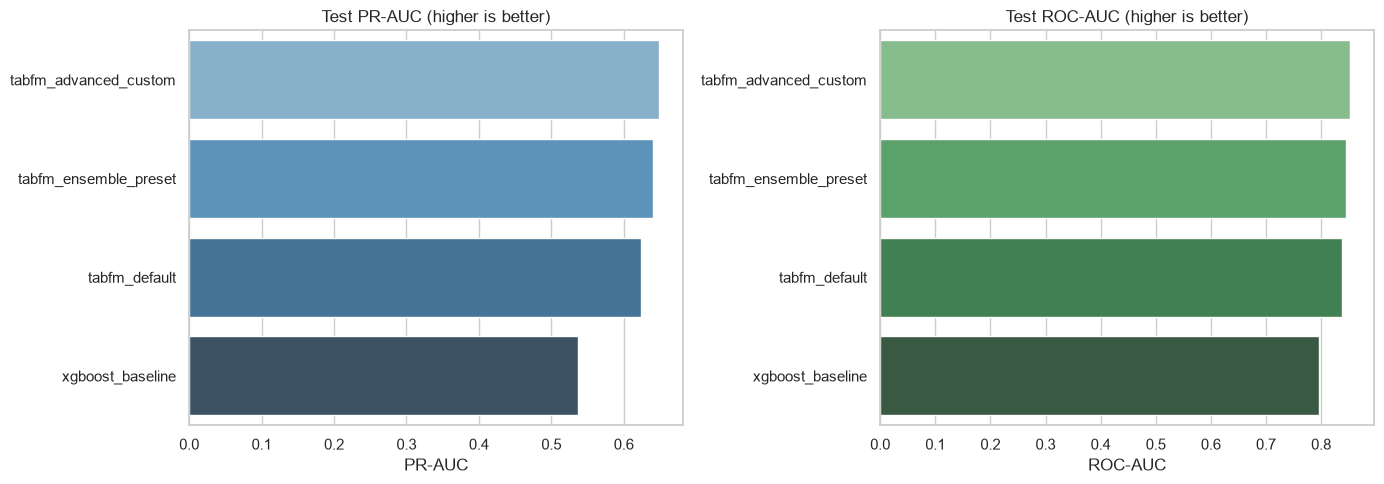

In [11]:
plot_df = metrics_df[metrics_df['split'] == 'test'].sort_values('pr_auc', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_df, y='model', x='pr_auc', ax=axes[0], palette='Blues_d')
axes[0].set_title('Test PR-AUC (higher is better)')
axes[0].set_xlabel('PR-AUC')
axes[0].set_ylabel('')

sns.barplot(data=plot_df, y='model', x='roc_auc', ax=axes[1], palette='Greens_d')
axes[1].set_title('Test ROC-AUC (higher is better)')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


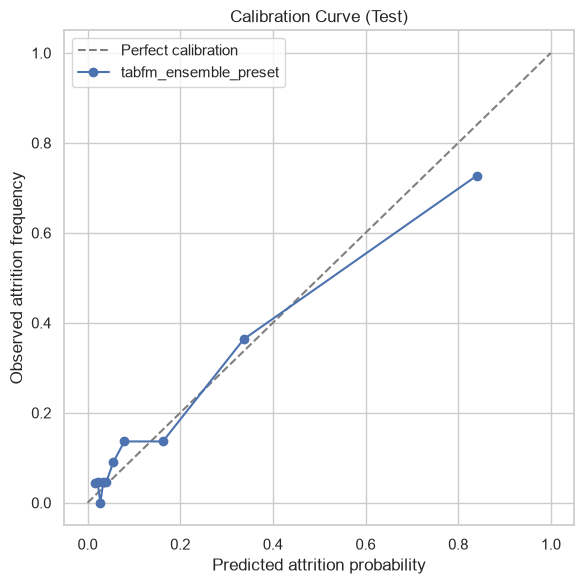

In [12]:
if len(champion_test_scores) != len(y_test_policy):
    raise ValueError(f'Champion score mismatch: len(scores)={len(champion_test_scores)} len(y_test_policy)={len(y_test_policy)}')

prob_true, prob_pred = calibration_curve(y_test_policy, champion_test_scores, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label=champion_model_name)
plt.title('Calibration Curve (Test)')
plt.xlabel('Predicted attrition probability')
plt.ylabel('Observed attrition frequency')
plt.legend()
plt.tight_layout()
plt.show()


## 10) Retention policy optimization

We convert probabilities into actions by maximizing expected net retention value.

Assumptions:

- Each targeted intervention has a direct cost.
- If a targeted employee would have left, intervention has a success probability.
- Saving an attrition event avoids replacement/onboarding cost proxy.


In [13]:
def optimize_retention_threshold(
    y_true: np.ndarray,
    y_score: np.ndarray,
    replacement_cost: np.ndarray,
    intervention_cost: float,
    retention_success_rate: float,
    grid_size: int = 401,
) -> tuple[pd.DataFrame, dict[str, float]]:
    thresholds = np.linspace(0.0, 1.0, grid_size)
    rows: list[dict[str, float]] = []

    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    replacement_cost = np.asarray(replacement_cost).astype(float)

    for thr in thresholds:
        targeted = y_score >= thr
        targeted_attriters = targeted & (y_true == 1)
        targeted_stayers = targeted & (y_true == 0)

        saved_turnover_value = float((replacement_cost[targeted_attriters] * retention_success_rate).sum())
        intervention_total_cost = float(targeted.sum() * intervention_cost)
        net_value = saved_turnover_value - intervention_total_cost

        rows.append({
            'threshold': float(thr),
            'targeted_count': float(targeted.sum()),
            'targeted_attriters': float(targeted_attriters.sum()),
            'targeted_stayers': float(targeted_stayers.sum()),
            'saved_turnover_value': saved_turnover_value,
            'intervention_cost_total': intervention_total_cost,
            'expected_net_value': net_value,
        })

    curve = pd.DataFrame(rows)
    best_idx = int(curve['expected_net_value'].idxmax())
    return curve, curve.loc[best_idx].to_dict()


def make_replacement_cost_proxy(meta: pd.DataFrame) -> np.ndarray:
    # Proxy: 1.2x annual salary, clipped for realism.
    monthly_income = pd.to_numeric(meta.get('MonthlyIncome', pd.Series(np.nan, index=meta.index)), errors='coerce')
    monthly_income = monthly_income.fillna(monthly_income.median())
    replacement_cost = (monthly_income * 12.0 * 1.2).clip(lower=20000.0, upper=300000.0)
    return replacement_cost.to_numpy(dtype=float)


BUSINESS_ASSUMPTIONS = {
    'intervention_cost': 1500.0,
    'retention_success_rate': 0.35,
}

val_replacement_cost = make_replacement_cost_proxy(val_meta_policy)
test_replacement_cost = make_replacement_cost_proxy(test_meta_policy)

threshold_curve_df, best_threshold_row = optimize_retention_threshold(
    y_true=y_val_policy,
    y_score=champion_val_scores,
    replacement_cost=val_replacement_cost,
    **BUSINESS_ASSUMPTIONS,
)
best_threshold = float(best_threshold_row['threshold'])
logger.info('Best retention threshold on validation: {:.3f}', best_threshold)

watchlist_threshold = max(0.0, best_threshold - 0.10)

policy_df = test_meta_policy.copy()
policy_df['is_leave'] = y_test_policy
policy_df['leave_score'] = champion_test_scores
policy_df['retention_action'] = np.select(
    [
        policy_df['leave_score'] >= best_threshold,
        policy_df['leave_score'] >= watchlist_threshold,
    ],
    ['priority_retention', 'watchlist'],
    default='stable',
)

policy_summary = (
    policy_df.groupby('retention_action', dropna=False)
    .agg(
        employees=('employee_id', 'count'),
        leave_rate=('is_leave', 'mean'),
        avg_leave_score=('leave_score', 'mean'),
    )
    .reset_index()
    .sort_values('employees', ascending=False)
)

policy_summary


2026-07-03 05:24:58.805 | INFO     | __main__:<module>:63 - Best retention threshold on validation: 0.013


,retention_action,employees,leave_rate,avg_leave_score
0,priority_retention,221,0.162896,0.160878


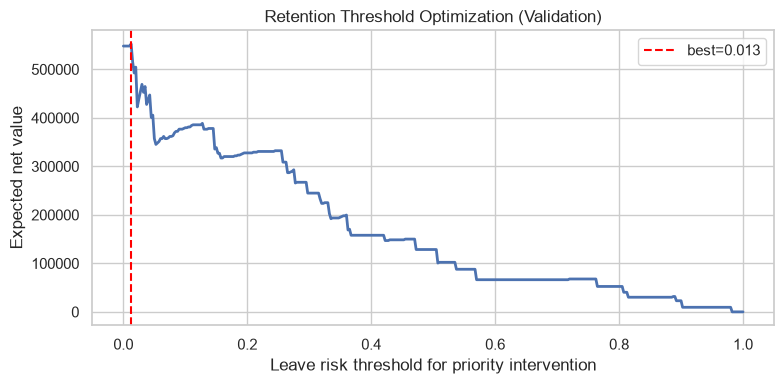

In [14]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=threshold_curve_df, x='threshold', y='expected_net_value', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best={best_threshold:.3f}')
plt.title('Retention Threshold Optimization (Validation)')
plt.xlabel('Leave risk threshold for priority intervention')
plt.ylabel('Expected net value')
plt.legend()
plt.tight_layout()
plt.show()


## 11) Persist artifacts


In [15]:
metrics_path = ARTIFACT_DIR / 'problem8_attrition_model_metrics.csv'
pred_path = ARTIFACT_DIR / 'problem8_attrition_predictions_test.parquet'
policy_path = ARTIFACT_DIR / 'problem8_attrition_retention_actions.csv'
policy_summary_path = ARTIFACT_DIR / 'problem8_attrition_policy_summary.csv'
threshold_curve_path = ARTIFACT_DIR / 'problem8_attrition_threshold_curve.csv'
threshold_summary_path = ARTIFACT_DIR / 'problem8_attrition_threshold_summary.csv'
runtime_meta_path = ARTIFACT_DIR / 'problem8_attrition_runtime_meta.json'

prediction_frame = policy_df[[
    'employee_id',
    'is_leave',
    'leave_score',
    'retention_action',
]].copy()

metrics_df.to_csv(metrics_path, index=False)
policy_df.to_csv(policy_path, index=False)
policy_summary.to_csv(policy_summary_path, index=False)
threshold_curve_df.to_csv(threshold_curve_path, index=False)

threshold_summary_df = pd.DataFrame([
    {'split': 'validation', **best_threshold_row},
    {
        'split': 'test',
        **optimize_retention_threshold(
            y_true=y_test_policy,
            y_score=champion_test_scores,
            replacement_cost=test_replacement_cost,
            **BUSINESS_ASSUMPTIONS,
        )[1],
    },
])
threshold_summary_df.to_csv(threshold_summary_path, index=False)

pred_cast = prediction_frame.copy()
pred_cast['employee_id'] = pd.to_numeric(pred_cast['employee_id'], errors='coerce').fillna(-1).astype('int64')
pred_cast['is_leave'] = pred_cast['is_leave'].astype('int32')
pred_cast['leave_score'] = pred_cast['leave_score'].astype('float64')
pred_cast['retention_action'] = pred_cast['retention_action'].astype(str)

pl.DataFrame({col: pred_cast[col].tolist() for col in pred_cast.columns}).write_parquet(pred_path)

runtime_meta = {
    'seed': SEED,
    'dataset_url': DATA_URL,
    'sample_train_rows': int(SAMPLE_TRAIN_ROWS),
    'sample_eval_rows': int(SAMPLE_EVAL_ROWS),
    'tabfm_context_max_rows': int(TABFM_CONTEXT_MAX_ROWS),
    'tabfm_eval_max_rows': int(TABFM_EVAL_MAX_ROWS),
    'tabfm_fast_mode': bool(TABFM_FAST_MODE),
    'tabfm_device_preference': TABFM_DEVICE_PREF,
    'tabfm_device_effective': TABFM_DEVICE_EFFECTIVE,
    'tabfm_checkpoint_override': str(TABFM_CKPT_PATH) if TABFM_CKPT_PATH else None,
    'champion_model': champion_model_name,
    'best_threshold': best_threshold,
    'business_assumptions': BUSINESS_ASSUMPTIONS,
    'policy_rows_val': int(len(y_val_policy)),
    'policy_rows_test': int(len(y_test_policy)),
}
runtime_meta_path.write_text(json.dumps(runtime_meta, indent=2))

for path in [
    metrics_path,
    pred_path,
    policy_path,
    policy_summary_path,
    threshold_curve_path,
    threshold_summary_path,
    runtime_meta_path,
]:
    logger.info('Wrote {}', path)

sorted(p.name for p in ARTIFACT_DIR.glob('problem8_attrition_*'))


2026-07-03 05:24:58.939 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts/problem8_attrition_model_metrics.csv


2026-07-03 05:24:58.940 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts/problem8_attrition_predictions_test.parquet


2026-07-03 05:24:58.940 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts/problem8_attrition_retention_actions.csv


2026-07-03 05:24:58.941 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts/problem8_attrition_policy_summary.csv


2026-07-03 05:24:58.941 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts/problem8_attrition_threshold_curve.csv


2026-07-03 05:24:58.941 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts/problem8_attrition_threshold_summary.csv


2026-07-03 05:24:58.941 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem8_employee_attrition_prediction/artifacts/problem8_attrition_runtime_meta.json


['problem8_attrition_model_metrics.csv',
 'problem8_attrition_policy_summary.csv',
 'problem8_attrition_predictions_test.parquet',
 'problem8_attrition_retention_actions.csv',
 'problem8_attrition_runtime_meta.json',
 'problem8_attrition_threshold_curve.csv',
 'problem8_attrition_threshold_summary.csv']

## 12) Deployment notes

For production HR retention operations:

1. Retrain monthly or quarterly (depending on workforce churn volatility).
2. Track drift in key features (`OverTime`, `MonthlyIncome`, tenure metrics, engagement indicators).
3. Monitor both discrimination and calibration metrics over time.
4. Human-in-the-loop review for high-risk cohorts before intervention rollout.
5. Run A/B tests on intervention strategies to estimate true uplift.
